# Comparing Strategies

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'font.family': 'sans-serif',
    'figure.facecolor': 'white',
})

BASE      = Path('../results_paper')          
MANDATORY = BASE / 'full_budget200'
FORCED    = BASE / 'forced_budget200'

TITLE = {0.0: 'Mono yield (λ=0)', 1.0: 'Penalised yield (λ=1)'}
YLAB  = {0.0: 'Best mono yield found (%)', 1.0: 'Best penalised yield found (%)'}


def ci95(x):
    """Half-width of the 95% confidence interval on the mean."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    return 0.0 if n < 2 else float(st.t.ppf(0.975, n - 1) * x.std(ddof=1) / np.sqrt(n))

## Load

In [2]:
stats_m  = pd.read_csv(MANDATORY / 'stats.csv')
curves_m = pd.read_csv(MANDATORY / 'curves.csv')
stats_f  = pd.read_csv(FORCED / 'stats_forced.csv')
curves_f = pd.read_csv(FORCED / 'curves_forced.csv')


def label_forced(df):
    df = df.copy()
    df['strategy'] = df['repeat_share_target'].map({
        0.1: '10% Repetitions', 0.2: '20% Repetitions',
        0.3: '30% Repetitions', 0.5: '50% Repetitions',
    })
    return df[df['strategy'].notna()]        


def label_mandatory(df):
    df = df.copy()
    df['strategy'] = df['mandatory_reps'].map(
        {0: 'Single', 1: 'Duplicate', 2: 'Triplicate'})
    return df


stats_f, curves_f = label_forced(stats_f),    label_forced(curves_f)
stats_m, curves_m = label_mandatory(stats_m), label_mandatory(curves_m)

stats  = pd.concat([stats_m,  stats_f],  ignore_index=True)
curves = pd.concat([curves_m, curves_f], ignore_index=True)
stats['loss'] = stats.final_best_true_f - stats.rec_obs_true

STRATEGY_ORDER = ['Single', '10% Repetitions', '20% Repetitions',
                  '30% Repetitions', '50% Repetitions', 'Duplicate', 'Triplicate']
STRATEGY_ORDER = [s for s in STRATEGY_ORDER if s in stats.strategy.unique()]

COLORS = {'Single': 'blue', '10% Repetitions': 'lightblue',
          '20% Repetitions': 'lightgreen', '30% Repetitions': 'green',
          '50% Repetitions': 'yellow', 'Duplicate': 'orange', 'Triplicate': 'red'}

MANDATORY_ORDER = ['Single', 'Duplicate', 'Triplicate']
N_SHARE = sum(1 for s in STRATEGY_ORDER if s.endswith('Repetitions')) + 1

print(f'{len(stats)} runs | {stats.seed.nunique()} seeds | {STRATEGY_ORDER}')

420 runs | 30 seeds | ['Single', '10% Repetitions', '20% Repetitions', '30% Repetitions', '50% Repetitions', 'Duplicate', 'Triplicate']


## Figure 1 — best condition evaluated

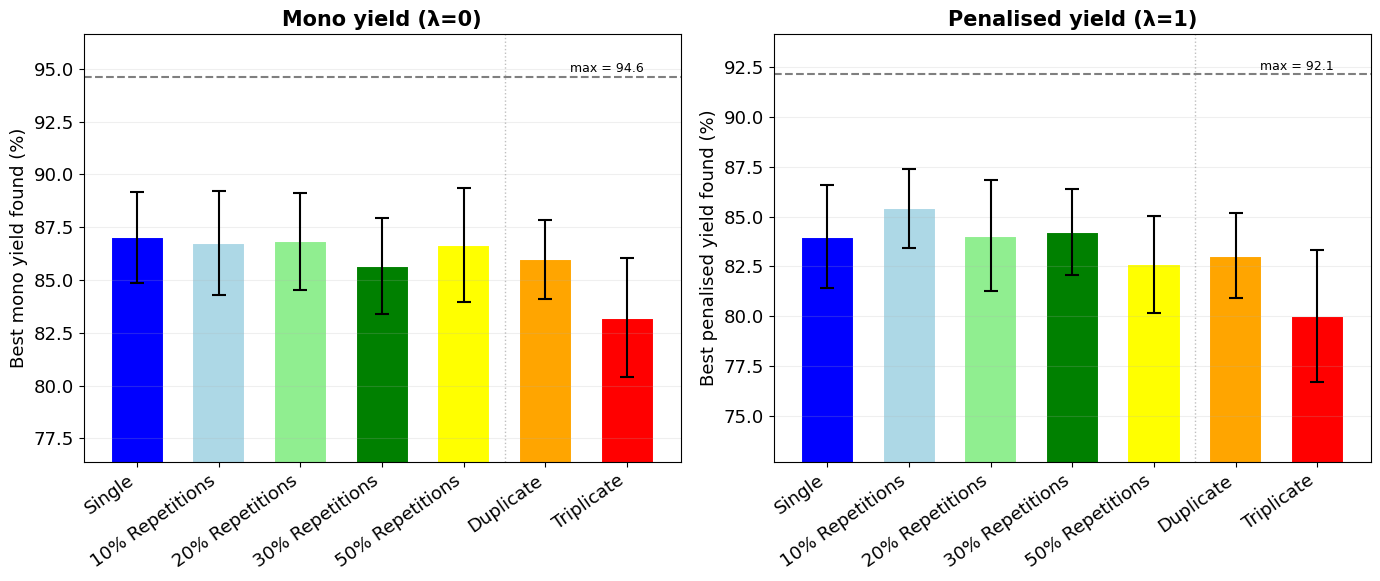

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, lam in zip(axes, [0.0, 1.0]):
    sub = stats[stats.lambda_di == lam]
    global_best = sub.global_best_true.iloc[0]

    labels = [s for s in STRATEGY_ORDER if not sub[sub.strategy == s].empty]
    means = np.array([sub[sub.strategy == s].final_best_true_f.mean() for s in labels])
    errs  = np.array([ci95(sub[sub.strategy == s].final_best_true_f) for s in labels])
    x = np.arange(len(labels))

    ax.bar(x, means, 0.65, yerr=errs, capsize=5,
           color=[COLORS[s] for s in labels],
           edgecolor='white', linewidth=1.5,
           error_kw={'lw': 1.5, 'capthick': 1.5})

    ax.axhline(global_best, color='black', ls='--', lw=1.5, alpha=0.5)
    ax.text(len(labels) - 0.8, global_best + 0.2, f'max = {global_best:.1f}',
            ha='right', fontsize=9, color='black')
    if 0 < N_SHARE < len(labels):
        ax.axvline(N_SHARE - 0.5, color='gray', ls=':', lw=1, alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.set_ylabel(YLAB[lam])
    ax.set_title(TITLE[lam], fontweight='bold')
    ax.grid(True, axis='y', alpha=0.2)
    ax.set_ylim(min(means - errs) - 4, max(global_best + 2, max(means + errs) + 3))

plt.tight_layout()
plt.show()

## Figure 2 — optimisation trajectories

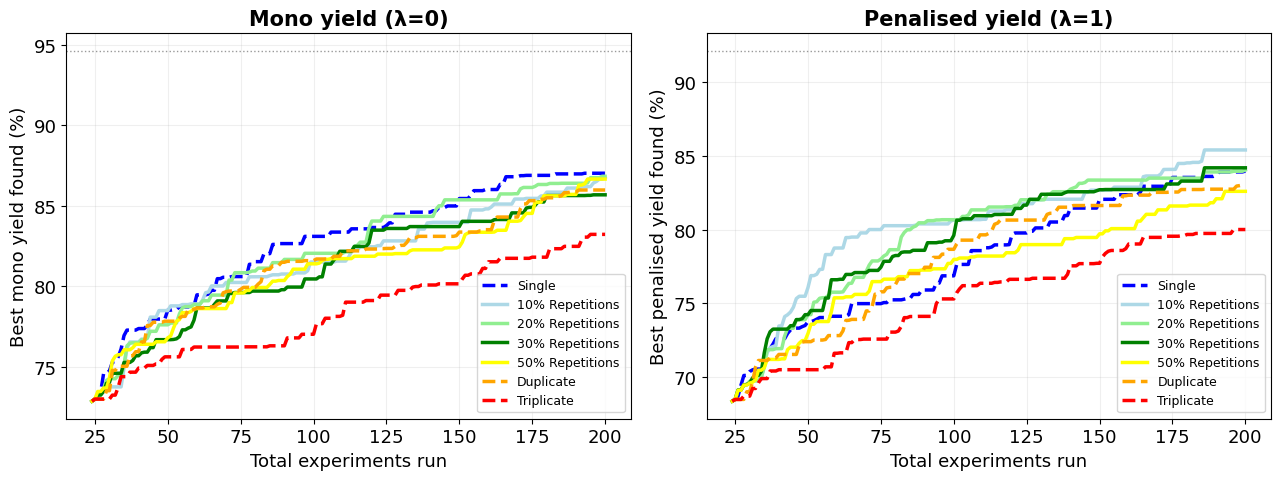

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, lam in zip(axes, [0.0, 1.0]):
    sub = curves[curves.lambda_di == lam]
    global_best = stats[stats.lambda_di == lam].global_best_true.iloc[0]

    for strat in STRATEGY_ORDER:
        s = sub[sub.strategy == strat]
        if s.empty:
            continue
        mean = s.groupby('experiments')['best_true_f'].mean()
        ls = '-' if strat.endswith('Repetitions') else '--'
        ax.plot(mean.index, mean.values, color=COLORS[strat],
                lw=2.5, ls=ls, label=strat)

    ax.axhline(global_best, color='black', ls=':', lw=1, alpha=0.4)
    ax.set_xlabel('Total experiments run')
    ax.set_ylabel(YLAB[lam])
    ax.set_title(TITLE[lam], fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Figure 3 — Wilcoxon p-value against budget

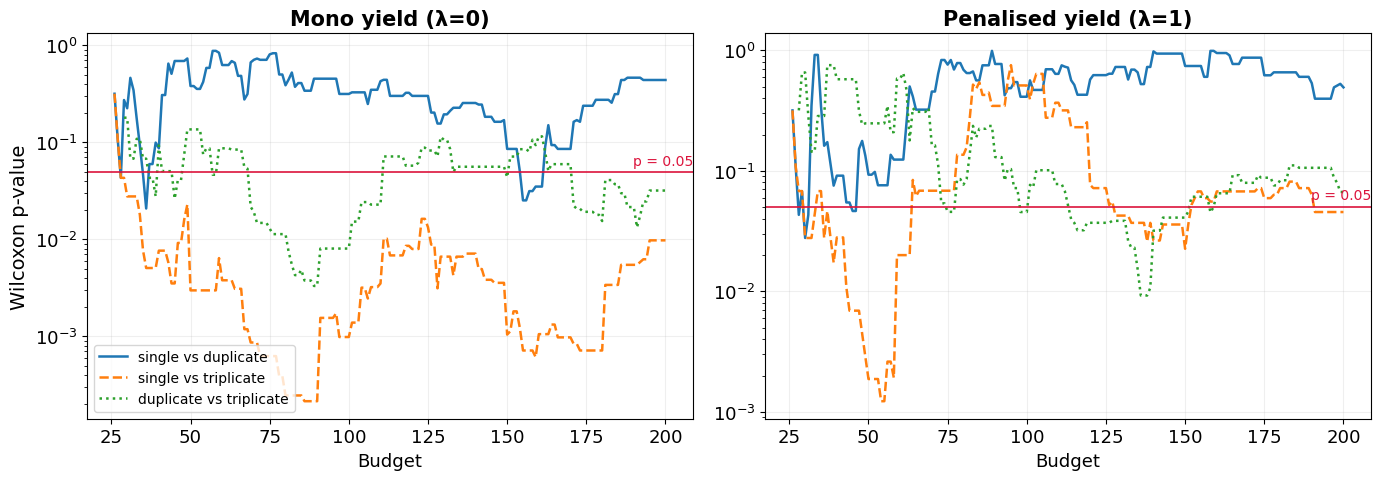

In [5]:
PAIRS = [('Single', 'Duplicate'), ('Single', 'Triplicate'),
         ('Duplicate', 'Triplicate')]
STYLE = {0: ('-', 'tab:blue'), 1: ('--', 'tab:orange'), 2: (':', 'tab:green')}


def wide(lam, strategy, metric='best_true_f'):
    """seeds x budget matrix for one strategy, from the mandatory runs."""
    s = curves_m[(curves_m.lambda_di == lam) & (curves_m.strategy == strategy)]
    return s.pivot_table(index='seed', columns='experiments',
                         values=metric).sort_index().sort_index(axis=1)


def p_by_budget(lam, a, b):
    A, B = wide(lam, a), wide(lam, b)
    budgets, pvals = [], []
    for t in [c for c in A.columns if c in B.columns]:
        xa, xb = A[t].values, B[t].values
        ok = ~(np.isnan(xa) | np.isnan(xb))
        xa, xb = xa[ok], xb[ok]
        if len(xa) < 3 or np.allclose(xa - xb, 0):
            continue
        budgets.append(t)
        pvals.append(st.wilcoxon(xa, xb).pvalue)
    return np.array(budgets), np.array(pvals)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lam in zip(axes, [0.0, 1.0]):
    for i, (a, b) in enumerate(PAIRS):
        bud, p = p_by_budget(lam, a, b)
        ls, c = STYLE[i]
        ax.plot(bud, p, ls, color=c, lw=1.8, label=f'{a.lower()} vs {b.lower()}')

    ax.axhline(0.05, color='crimson', lw=1.2)
    ax.text(ax.get_xlim()[1], 0.055, 'p = 0.05', color='crimson',
            fontsize=10, ha='right', va='bottom')
    ax.set_yscale('log')
    ax.set_xlabel('Budget')
    ax.set_title(TITLE[lam], fontweight='bold')
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel(fontsize=14, ylabel='Wilcoxon p-value')
axes[0].legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.show()

## Table 1 — best evaluated, recommended, identification loss

In [6]:
def fmt(x):
    return f'{x.mean():.2f} +- {ci95(x):.2f}'


rows = []
for lam in [0.0, 1.0]:
    sub = stats[stats.lambda_di == lam]
    for strat in MANDATORY_ORDER:
        x = sub[sub.strategy == strat]
        rows.append({
            'objective': TITLE[lam], 'strategy': strat,
            'best available': f'{x.global_best_true.iloc[0]:.2f}',
            'best evaluated': fmt(x.final_best_true_f),
            'recommended':    fmt(x.rec_obs_true),
            'loss':           fmt(x.loss),
        })
tab1 = pd.DataFrame(rows)
print(tab1.to_string(index=False))

            objective   strategy best available best evaluated   recommended          loss
     Mono yield (λ=0)     Single          94.63  87.02 +- 2.16 76.57 +- 5.05 10.45 +- 5.00
     Mono yield (λ=0)  Duplicate          94.63  85.98 +- 1.88 83.26 +- 3.81  2.72 +- 2.65
     Mono yield (λ=0) Triplicate          94.63  83.22 +- 2.83 80.98 +- 4.11  2.24 +- 2.44
Penalised yield (λ=1)     Single          92.15  83.98 +- 2.58 76.39 +- 5.16  7.59 +- 3.94
Penalised yield (λ=1)  Duplicate          92.15  83.04 +- 2.13 81.59 +- 3.14  1.44 +- 1.72
Penalised yield (λ=1) Triplicate          92.15  80.02 +- 3.32 79.37 +- 3.66  0.65 +- 0.82


## Table 2 — paired comparisons

In [8]:
QUANTITIES = [('final_best_true_f', 'Best evaluated'),
              ('rec_obs_true',      'Recommended'),
              ('loss',              'Identification loss')]


def paired(lam, metric, a, b):
    sub = stats[stats.lambda_di == lam]
    xa = sub[sub.strategy == a].sort_values('seed')[metric].values
    xb = sub[sub.strategy == b].sort_values('seed')[metric].values
    return st.wilcoxon(xa, xb).pvalue, st.ttest_rel(xa, xb).pvalue


def show(p):
    return f'{p:.3f}' if p >= 0.001 else f'{p:.4f}'


rows = []
for metric, qname in QUANTITIES:
    for a, b in PAIRS:
        w0, t0 = paired(0.0, metric, a, b)
        w1, t1 = paired(1.0, metric, a, b)
        rows.append({'quantity': qname, 'comparison': f'{a} - {b}',
                     'mono W': show(w0), 'mono t': show(t0),
                     'pen W':  show(w1), 'pen t':  show(t1),
                     'sig (W)': 'yes/yes' if (w0 < .05 and w1 < .05) else
                                'yes/no' if w0 < .05 else
                                'no/yes' if w1 < .05 else 'no/no'})
tab2 = pd.DataFrame(rows)
print(tab2.to_string(index=False))

           quantity             comparison mono W mono t pen W pen t sig (W)
     Best evaluated     Single - Duplicate  0.440  0.363 0.493 0.522   no/no
     Best evaluated    Single - Triplicate  0.010  0.009 0.046 0.050 yes/yes
     Best evaluated Duplicate - Triplicate  0.032  0.046 0.067 0.062  yes/no
        Recommended     Single - Duplicate  0.119  0.029 0.130 0.085   no/no
        Recommended    Single - Triplicate  0.456  0.122 0.349 0.327   no/no
        Recommended Duplicate - Triplicate  0.104  0.104 0.187 0.188   no/no
Identification loss     Single - Duplicate  0.016  0.011 0.014 0.006 yes/yes
Identification loss    Single - Triplicate  0.008  0.006 0.002 0.001 yes/yes
Identification loss Duplicate - Triplicate  0.028  0.025 0.214 0.285  yes/no


## Extra tables — all strategies compared

In [9]:
SHORT = {'Single': 'Single', '10% Repetitions': '10%', '20% Repetitions': '20%',
         '30% Repetitions': '30%', '50% Repetitions': '50%',
         'Duplicate': 'Duplicate', 'Triplicate': 'Triplicate'}

for lam in [0.0, 1.0]:
    sub = stats[stats.lambda_di == lam]
    print(f'\n{TITLE[lam]}   (best available: {sub.global_best_true.iloc[0]:.2f})')
    print('-' * 72)
    print(f'{"Strategy":<12}{"Best evaluated":>16}{"Recommended":>16}{"Loss":>16}{"Conds":>8}')
    for strat in STRATEGY_ORDER:
        x = sub[sub.strategy == strat]
        if x.empty:
            continue
        print(f'{SHORT[strat]:<12}{fmt(x.final_best_true_f):>16}'
              f'{fmt(x.rec_obs_true):>16}{fmt(x.loss):>16}'
              f'{x.n_unique_conds.mean():>8.0f}')


Mono yield (λ=0)   (best available: 94.63)
------------------------------------------------------------------------
Strategy      Best evaluated     Recommended            Loss   Conds
Single         87.02 +- 2.16   76.57 +- 5.05   10.45 +- 5.00     200
10%            86.75 +- 2.48   81.42 +- 4.56    5.33 +- 3.11     183
20%            86.83 +- 2.31   79.84 +- 5.05    6.99 +- 3.71     164
30%            85.68 +- 2.27   75.77 +- 5.47    9.91 +- 4.72     146
50%            86.66 +- 2.68   81.88 +- 4.09    4.77 +- 3.46     112
Duplicate      85.98 +- 1.88   83.26 +- 3.81    2.72 +- 2.65     120
Triplicate     83.22 +- 2.83   80.98 +- 4.11    2.24 +- 2.44      87

Penalised yield (λ=1)   (best available: 92.15)
------------------------------------------------------------------------
Strategy      Best evaluated     Recommended            Loss   Conds
Single         83.98 +- 2.58   76.39 +- 5.16    7.59 +- 3.94     200
10%            85.42 +- 1.97   77.57 +- 4.73    7.84 +- 3.51     183
20

In [10]:
from itertools import combinations

ALL_PAIRS = list(combinations(STRATEGY_ORDER, 2))

for metric, qname in QUANTITIES:
    print(f'\n{qname}')
    print('-' * 78)
    print(f'{"Comparison":<28}{"Mono: W":>10}{"t":>8}{"Pen: W":>10}{"t":>8}   sig (W)')
    for a, b in ALL_PAIRS:
        w0, t0 = paired(0.0, metric, a, b)
        w1, t1 = paired(1.0, metric, a, b)
        sig = ('mono, pen' if w0 < .05 and w1 < .05 else
               'mono'      if w0 < .05 else
               'pen'       if w1 < .05 else '-')
        label = f'{SHORT[a]} - {SHORT[b]}'
        print(f'{label:<28}{show(w0):>10}{show(t0):>8}'
              f'{show(w1):>10}{show(t1):>8}   {sig}')


Best evaluated
------------------------------------------------------------------------------
Comparison                     Mono: W       t    Pen: W       t   sig (W)
Single - 10%                     0.792   0.834     0.274   0.197   -
Single - 20%                     0.946   0.889     0.707   0.956   -
Single - 30%                     0.469   0.372     0.981   0.880   -
Single - 50%                     0.496   0.805     0.280   0.326   -
Single - Duplicate               0.440   0.363     0.493   0.522   -
Single - Triplicate              0.010   0.009     0.046   0.050   mono, pen
10% - 20%                        0.859   0.953     0.319   0.166   -
10% - 30%                        0.406   0.453     0.244   0.285   -
10% - 50%                        0.939   0.934     0.014   0.029   pen
10% - Duplicate                  0.603   0.527     0.041   0.054   pen
10% - Triplicate                 0.039   0.029     0.006   0.003   mono, pen
20% - 30%                        0.404   0.352     